# 02c — EDA exploratoria del panel OHLCV limpio

> **LEGACY SNAPSHOT:** conserva el análisis previo a common-core-1.0.0. No es evidencia de certificación; usar `tests/` y `COMMON_CORE_CERTIFICATION.md`.

Notebook **playground**: explorar la naturaleza de los datos ticker a ticker y en conjunto.

- Entrada **solo lectura**: `data/clean/ohlcv_clean.parquet` (+ `clean_manifest.json`).
- **No** re-descarga, **no** re-limpia, **no** sobrescribe `data/clean/`.
- Returns / rangos aquí son **exploratorios**
- Puedes añadir celdas (“ahora quiero ver X”). Si descubres un problema grave de datos: **documentarlo**, no “arreglar” el canónico aquí.


## 1. Setup + verificación SHA clean

Si el SHA no coincide → **PARA** (no continuar la EDA sobre un artefacto distinto al canónico).


In [ ]:
from __future__ import annotations

import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Raíz del repo (cwd = TALLER_B5_T1/ o notebooks/)
ROOT = Path.cwd()
if not (ROOT / "data" / "clean" / "ohlcv_clean.parquet").is_file():
    if (ROOT.parent / "data" / "clean" / "ohlcv_clean.parquet").is_file():
        ROOT = ROOT.parent
    else:
        raise FileNotFoundError(
            "No se encuentra data/clean/ohlcv_clean.parquet. Ejecutar desde la raíz del repo."
        )

CLEAN_PATH = ROOT / "data" / "clean" / "ohlcv_clean.parquet"
MANIFEST_PATH = ROOT / "data" / "clean" / "clean_manifest.json"
FIGS_DIR = ROOT / "notebooks" / "figures"

EXPECTED_CLEAN_SHA256 = (
    "fb1d9e60853743fff8cf6a2b17fb7588915d4213022c75b7311f33944a974f25"
)

# Controles del playground (editar libremente)
USE_LOG_SCALE = True          # Close en escala log
DATE_START = None             # ej. "2020-01-01" para zoom temporal
DATE_END = None               # ej. "2024-12-31"
TICKER = "NVDA"               # drill-down (§8)
SAVE_FIGS = False             # True → exporta notebooks/figures/02c_*.png
FIGSIZE = (11, 4)


def sha256_file(path: Path) -> str:
    h = hashlib.sha256()
    with path.open("rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()


def maybe_save(fig: plt.Figure, name: str) -> None:
    if not SAVE_FIGS:
        return
    FIGS_DIR.mkdir(parents=True, exist_ok=True)
    out = FIGS_DIR / name
    fig.savefig(out, dpi=120, bbox_inches="tight")
    print(f"fig → {out.relative_to(ROOT)}")


clean_sha = sha256_file(CLEAN_PATH)
sha_ok = clean_sha == EXPECTED_CLEAN_SHA256

display(
    pd.DataFrame(
        [
            {
                "artifact": "ohlcv_clean.parquet",
                "path": str(CLEAN_PATH.relative_to(ROOT)),
                "expected": EXPECTED_CLEAN_SHA256,
                "actual": clean_sha,
                "ok": sha_ok,
            }
        ]
    )
)

if not sha_ok:
    raise RuntimeError(
        "BLOQUEADO: SHA256 de ohlcv_clean.parquet no coincide con el canónico. "
        "No continuar la EDA hasta resolver el artefacto (orquestador)."
    )

print("SHA256 clean: OK")

with MANIFEST_PATH.open() as f:
    manifest = json.load(f)

print(
    f"manifest data_version={manifest.get('data_version')} | "
    f"rows_out={manifest.get('rows_out')} | "
    f"date_min={manifest.get('date_min')} → date_max={manifest.get('date_max')} | "
    f"n_tickers={len(manifest.get('tickers_out', []))}"
)


,artifact,path,expected,actual,ok
0,ohlcv_clean.parquet,data/clean/ohlcv_clean.parquet,fb1d9e60853743fff8cf6a2b17fb7588915d4213022c75...,fb1d9e60853743fff8cf6a2b17fb7588915d4213022c75...,True


SHA256 clean: OK
manifest data_version=clean-0.1.0 | rows_out=38713 | date_min=2012-01-03 → date_max=2025-12-31 | n_tickers=11


## 2. Vista global

Shape, rango de fechas, tickers, días por ticker. Filtro temporal opcional vía `DATE_START` / `DATE_END` (§1).

<!-- Ampliar: cobertura vs calendario unión, huecos por ticker, calendarios parciales INTC/MCHP/... -->


In [10]:
df = pd.read_parquet(CLEAN_PATH)
df["date"] = pd.to_datetime(df["date"]).dt.normalize()
df = df.sort_values(["date", "ticker"]).reset_index(drop=True)

# Filtro exploratorio (no modifica el parquet)
if DATE_START is not None:
    df = df.loc[df["date"] >= pd.Timestamp(DATE_START)].copy()
if DATE_END is not None:
    df = df.loc[df["date"] <= pd.Timestamp(DATE_END)].copy()

tickers = sorted(df["ticker"].unique().tolist())
days_per_ticker = df.groupby("ticker")["date"].nunique().reindex(tickers)

summary = pd.Series(
    {
        "rows": len(df),
        "n_tickers": len(tickers),
        "date_min": df["date"].min(),
        "date_max": df["date"].max(),
        "n_dates_union": df["date"].nunique(),
        "cols": list(df.columns),
    }
)
display(summary.to_frame("value"))
print("tickers:", tickers)
display(days_per_ticker.rename("n_days").to_frame())

# Huecos vs calendario unión del panel (tras filtro)
cal = pd.Index(sorted(df["date"].unique()))
gaps = {t: int(len(cal) - days_per_ticker[t]) for t in tickers}
gaps_s = pd.Series(gaps, name="missing_vs_union").sort_values(ascending=False)
display(gaps_s.to_frame())

df.head(3)


,value
rows,38713
n_tickers,11
date_min,2012-01-03 00:00:00
date_max,2025-12-31 00:00:00
n_dates_union,3520
cols,"[date, ticker, Open, High, Low, Close, Volume]"


tickers: ['ADI', 'AMD', 'AVGO', 'INTC', 'MCHP', 'MRVL', 'MU', 'NVDA', 'NXPI', 'QCOM', 'TXN']


,n_days
ticker,
ADI,3520
AMD,3520
AVGO,3520
INTC,3517
MCHP,3518
MRVL,3519
MU,3520
NVDA,3520
NXPI,3520


,missing_vs_union
INTC,3
MCHP,2
MRVL,1
TXN,1
AVGO,0
ADI,0
AMD,0
MU,0
NVDA,0
NXPI,0


,date,ticker,Open,High,Low,Close,Volume
0,2012-01-03,ADI,26.486408,26.668021,26.086861,26.174034,3021500
1,2012-01-03,AMD,5.530000,5.590000,5.440000,5.480000,12675100
2,2012-01-03,AVGO,2.100463,2.149626,2.058425,2.062700,23032000


## 3. Series de precio (Close)

Overlay + paneles por ticker. Escala log controlada por `USE_LOG_SCALE` en §1.

<!-- Ampliar: normalizar a 100 en t0; comparar subperiodos; split-adjusted check visual -->


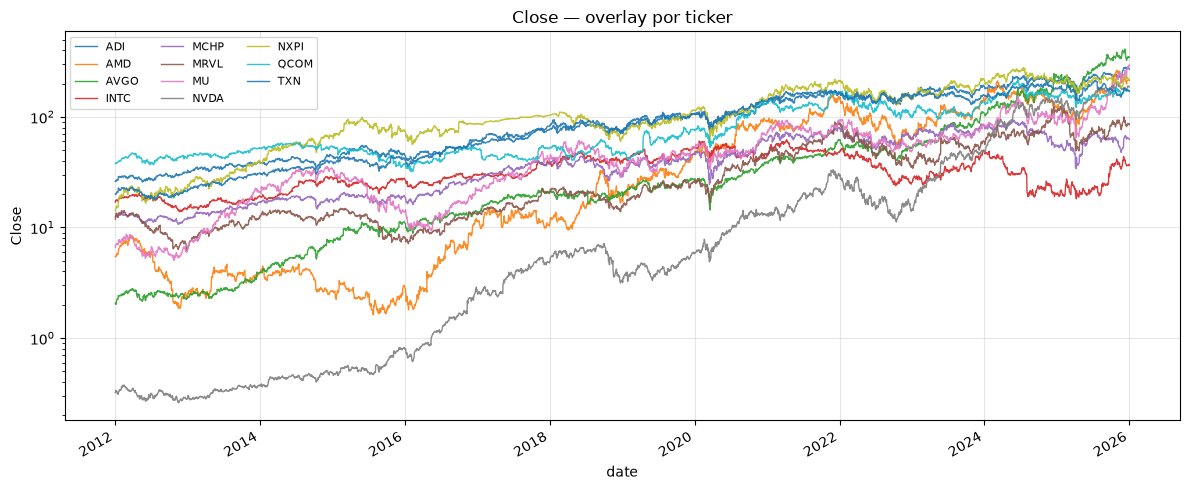

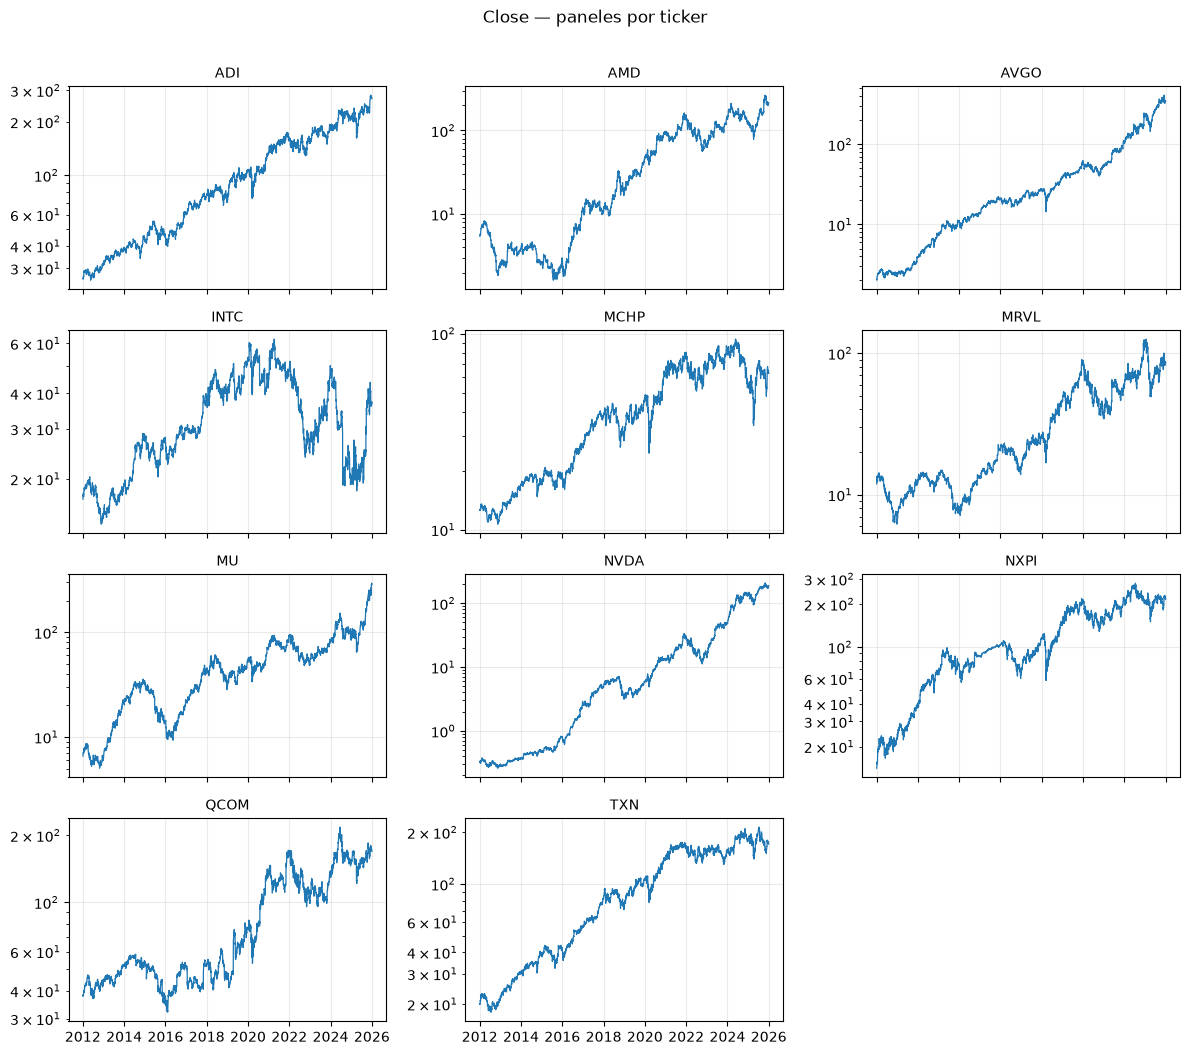

In [3]:
close_wide = df.pivot(index="date", columns="ticker", values="Close").sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
close_wide.plot(ax=ax, linewidth=1.0, alpha=0.9)
ax.set_title("Close — overlay por ticker")
ax.set_ylabel("Close")
if USE_LOG_SCALE:
    ax.set_yscale("log")
ax.legend(ncol=3, fontsize=8, loc="upper left")
ax.grid(True, alpha=0.3)
fig.tight_layout()
maybe_save(fig, "02c_close_overlay.png")
plt.show()

n = len(tickers)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 2.6 * nrows), sharex=True)
axes = np.atleast_1d(axes).ravel()
for i, t in enumerate(tickers):
    ax = axes[i]
    s = close_wide[t].dropna()
    ax.plot(s.index, s.values, color="C0", linewidth=0.9)
    ax.set_title(t, fontsize=10)
    if USE_LOG_SCALE:
        ax.set_yscale("log")
    ax.grid(True, alpha=0.25)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle("Close — paneles por ticker", y=1.01)
fig.tight_layout()
maybe_save(fig, "02c_close_panels.png")
plt.show()


## 4. Volumen

Distribución y series. Destacar `Volume == 0` si aparece (artefacto raro; no “corregir” aquí).

<!-- Ampliar: volumen en log; volumen relativo a media móvil; días de bajo liquidez -->


filas con Volume == 0: 1


,date,ticker,Open,High,Low,Close,Volume
8291,2015-01-02,AMD,2.67,2.67,2.67,2.67,0


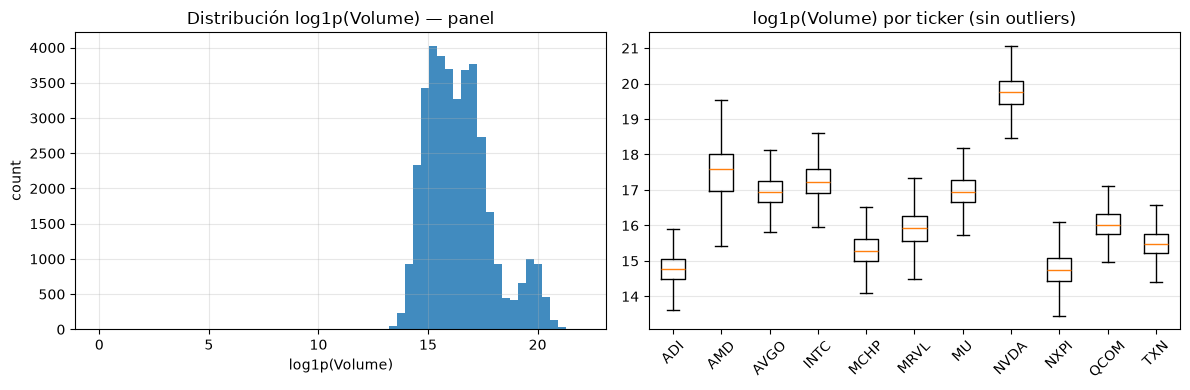

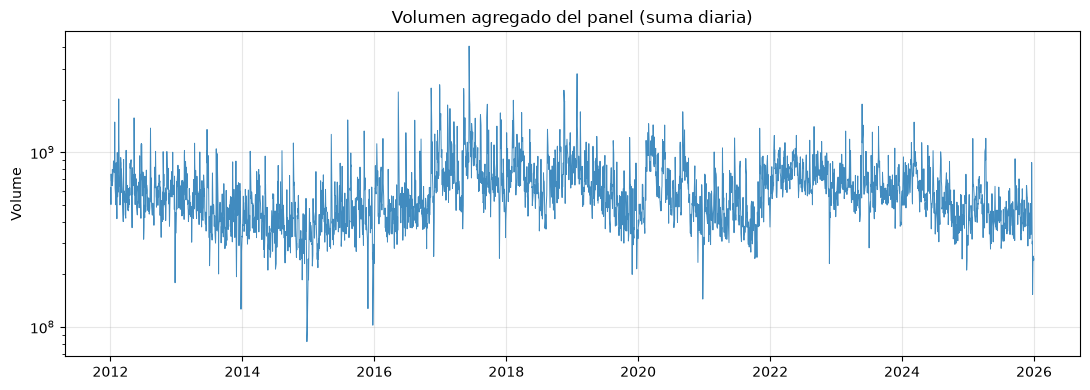

In [4]:
vol0 = df.loc[df["Volume"] == 0, ["date", "ticker", "Open", "High", "Low", "Close", "Volume"]]
print(f"filas con Volume == 0: {len(vol0)}")
if len(vol0):
    display(vol0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# histograma log1p(Volume)
axes[0].hist(np.log1p(df["Volume"]), bins=60, color="C0", edgecolor="none", alpha=0.85)
axes[0].set_title("Distribución log1p(Volume) — panel")
axes[0].set_xlabel("log1p(Volume)")
axes[0].set_ylabel("count")
axes[0].grid(True, alpha=0.3)

# boxplot por ticker (log1p)
data_box = [np.log1p(df.loc[df["ticker"] == t, "Volume"].astype(float)) for t in tickers]
axes[1].boxplot(data_box, tick_labels=tickers, showfliers=False)
axes[1].set_title("log1p(Volume) por ticker (sin outliers)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, alpha=0.3, axis="y")
fig.tight_layout()
maybe_save(fig, "02c_volume_dist.png")
plt.show()

# serie de volumen del panel (suma diaria) + un ticker ejemplo
vol_sum = df.groupby("date")["Volume"].sum()
fig, ax = plt.subplots(figsize=FIGSIZE)
ax.plot(vol_sum.index, vol_sum.values, linewidth=0.7, alpha=0.85)
ax.set_title("Volumen agregado del panel (suma diaria)")
ax.set_ylabel("Volume")
ax.set_yscale("log")
ax.grid(True, alpha=0.3)
fig.tight_layout()
maybe_save(fig, "02c_volume_agg.png")
plt.show()


## 5. Returns diarios exploratorios — $\ln(C_t / C_{t-1})$

**Solo análisis exploratorio** (no escribe features canónicas). Por ticker: histograma, estadísticos, boxplots comparativos.

<!-- Ampliar: QQ-plot; rolling vol; cola izquierda; subperiodos crisis 2020 / 2022 -->


,count,mean,std,skew,kurtosis
ticker,,,,,
ADI,3519,0.000663,0.018849,-0.057274,9.053835
AMD,3519,0.001042,0.035350,0.365681,9.878185
AVGO,3519,0.001455,0.023667,-0.052648,10.151317
INTC,3516,0.000221,0.022778,-0.575345,18.729809
MCHP,3517,0.000456,0.023128,-0.213245,11.663088
MRVL,3518,0.000558,0.028553,-0.134986,9.706123
MU,3519,0.001071,0.029381,-0.255137,3.922211
NVDA,3519,0.001808,0.028091,0.173590,7.934565
NXPI,3519,0.000774,0.025263,-0.132743,7.756398


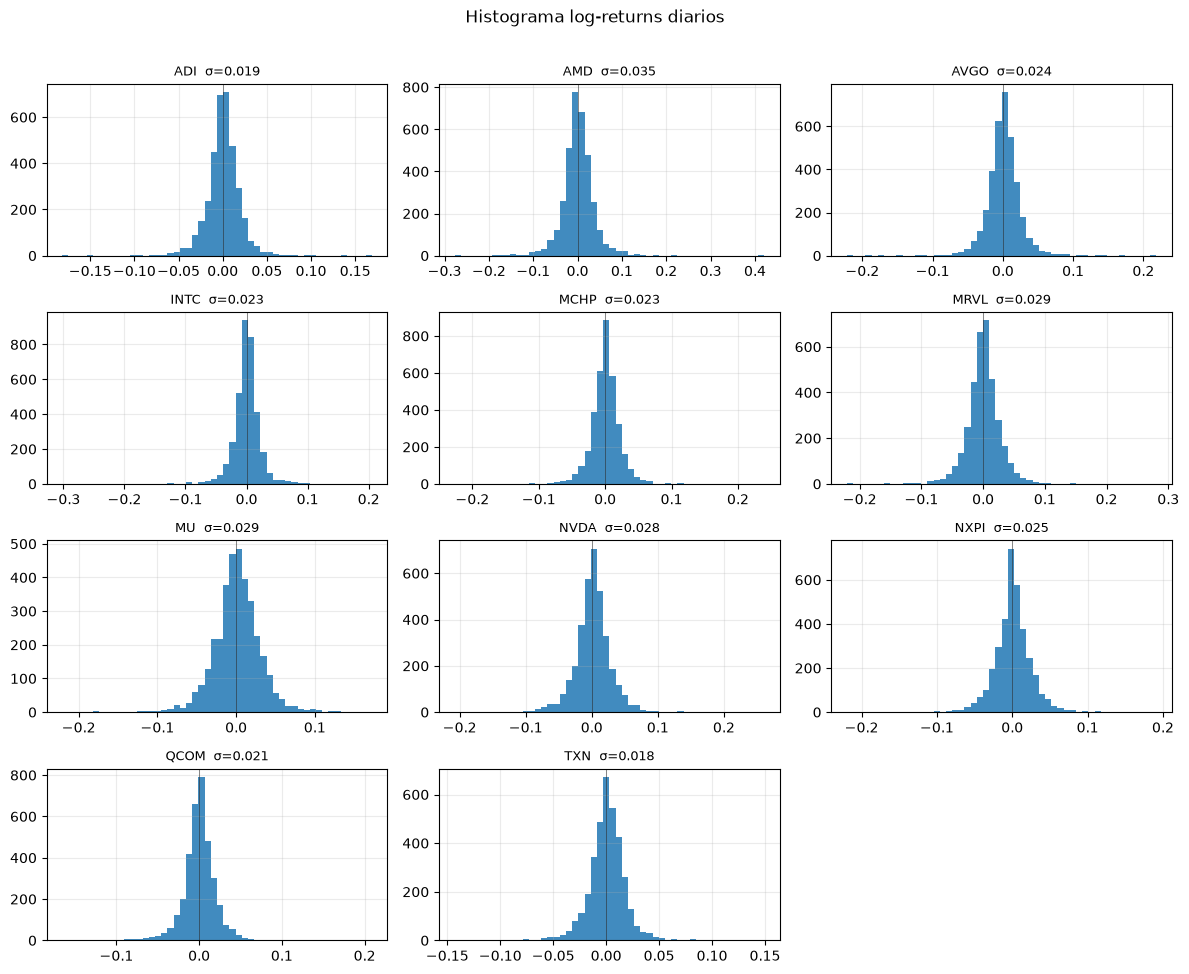

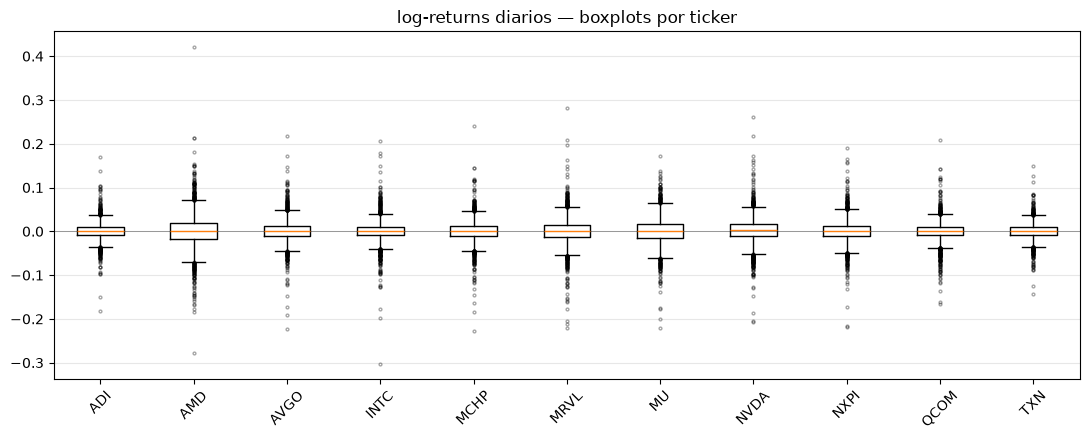

días con |log_ret| > 0.15: 67


,date,ticker,Close,log_ret
11897,2016-04-22,AMD,3.990000,0.420617
34811,2024-08-02,INTC,21.344599,-0.301896
31546,2023-05-26,MRVL,64.840233,0.280836
14734,2017-05-02,AMD,10.320000,-0.277456
13465,2016-11-11,NVDA,2.160569,0.260876
36693,2025-04-09,MCHP,43.119122,0.239423
22679,2020-03-16,MCHP,24.534166,-0.226830
22677,2020-03-16,AVGO,16.078474,-0.222056
22681,2020-03-16,MU,33.612980,-0.220878
36430,2025-03-06,MRVL,71.985542,-0.220817


In [ ]:
# Returns exploratorios
work = df.sort_values(["ticker", "date"]).copy()
work["log_ret"] = work.groupby("ticker", sort=False)["Close"].transform(
    lambda s: np.log(s / s.shift(1))
)
rets = work.dropna(subset=["log_ret"]).copy()

ret_stats = (
    rets.groupby("ticker")["log_ret"]
    .agg(count="count", mean="mean", std="std", skew="skew")
    .reindex(tickers)
)
ret_stats["kurtosis"] = rets.groupby("ticker")["log_ret"].apply(lambda s: s.kurtosis())
ret_stats = ret_stats.reindex(tickers)
display(ret_stats.round(6))

# histogramas por ticker (muestra subset si muchos)
ncols = 3
nrows = int(np.ceil(len(tickers) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(12, 2.4 * nrows))
axes = np.atleast_1d(axes).ravel()
for i, t in enumerate(tickers):
    ax = axes[i]
    x = rets.loc[rets["ticker"] == t, "log_ret"]
    ax.hist(x, bins=50, color="C0", edgecolor="none", alpha=0.85)
    ax.set_title(f"{t}  σ={x.std():.3f}", fontsize=9)
    ax.axvline(0, color="k", linewidth=0.6, alpha=0.5)
    ax.grid(True, alpha=0.25)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
fig.suptitle("Histograma log-returns diarios", y=1.01)
fig.tight_layout()
maybe_save(fig, "02c_returns_hist.png")
plt.show()

# boxplots comparativos
fig, ax = plt.subplots(figsize=(11, 4.5))
box_data = [rets.loc[rets["ticker"] == t, "log_ret"].values for t in tickers]
ax.boxplot(box_data, tick_labels=tickers, showfliers=True, flierprops=dict(markersize=2, alpha=0.35))
ax.axhline(0, color="k", linewidth=0.6, alpha=0.4)
ax.set_title("log-returns diarios — boxplots por ticker")
ax.tick_params(axis="x", rotation=45)
ax.grid(True, alpha=0.3, axis="y")
fig.tight_layout()
maybe_save(fig, "02c_returns_box.png")
plt.show()

# rarezas: |ret| grandes
big = rets.loc[rets["log_ret"].abs() > 0.15, ["date", "ticker", "Close", "log_ret"]].sort_values(
    "log_ret", key=lambda s: s.abs(), ascending=False
)
print(f"días con |log_ret| > 0.15: {len(big)}")
display(big.head(15))


## 6. Rango relativo diario

Comparación entre tickers de $(H-L)/C$ y $\ln(H/L)$.

<!-- Ampliar: correlación rango↔|return|; días de rango extremo -->


hl_over_c                         ln_hl                    
            mean    median       std      mean    median       std
ticker                                                            
ADI     0.021845  0.018831  0.012389  0.021859  0.018868  0.012466
AMD     0.041379  0.035828  0.021541  0.041384  0.035792  0.021604
AVGO    0.026666  0.023014  0.015366  0.026677  0.023084  0.015362
INTC    0.023828  0.019973  0.015139  0.023827  0.019963  0.015137
MCHP    0.025679  0.021929  0.015311  0.025679  0.021963  0.015352
MRVL    0.032549  0.028251  0.017640  0.032546  0.028211  0.017623
MU      0.034820  0.031092  0.016839  0.034803  0.031139  0.016784
NVDA    0.032002  0.027153  0.018394  0.032018  0.027205  0.018370
NXPI    0.028697  0.025857  0.017789  0.028714  0.025932  0.017861
QCOM    0.023095  0.019624  0.014583  0.023094  0.019650  0.014648
TXN     0.020276  0.017795  0.011038  0.020282  0.017798  0.011058

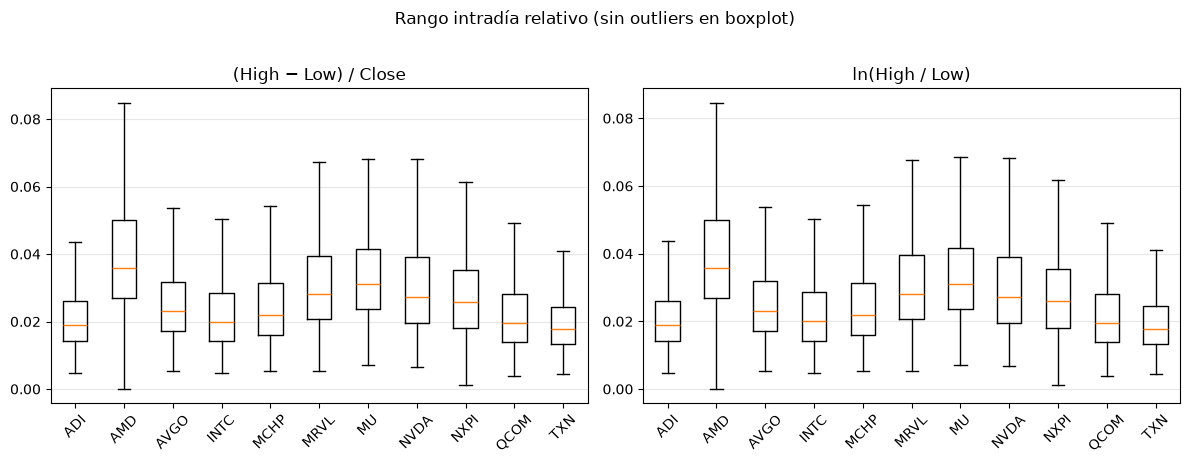

In [6]:
rng = work.copy()
rng["hl_over_c"] = (rng["High"] - rng["Low"]) / rng["Close"]
rng["ln_hl"] = np.log(rng["High"] / rng["Low"])

range_stats = (
    rng.groupby("ticker")[["hl_over_c", "ln_hl"]]
    .agg(["mean", "median", "std"])
    .reindex(tickers)
)
display(range_stats.round(6))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for ax, col, title in zip(
    axes,
    ["hl_over_c", "ln_hl"],
    ["(High − Low) / Close", "ln(High / Low)"],
):
    data = [rng.loc[rng["ticker"] == t, col].values for t in tickers]
    ax.boxplot(data, tick_labels=tickers, showfliers=False)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.3, axis="y")
fig.suptitle("Rango intradía relativo (sin outliers en boxplot)", y=1.02)
fig.tight_layout()
maybe_save(fig, "02c_range_box.png")
plt.show()


## 7. Correlación entre tickers

Matriz de correlaciones de returns diarios alineados por fecha (pairwise).

<!-- Ampliar: rolling corr NVDA–AMD; clusters; periodo pre/post-2020 -->


ticker,ADI,AMD,AVGO,INTC,MCHP,MRVL,MU,NVDA,NXPI,QCOM,TXN
ticker,,,,,,,,,,,
ADI,1.000,0.484,0.636,0.555,0.821,0.595,0.597,0.588,0.730,0.629,0.817
AMD,0.484,1.000,0.424,0.365,0.484,0.475,0.462,0.564,0.428,0.434,0.477
AVGO,0.636,0.424,1.000,0.458,0.611,0.583,0.562,0.583,0.601,0.560,0.601
INTC,0.555,0.365,0.458,1.000,0.580,0.459,0.495,0.447,0.487,0.486,0.578
MCHP,0.821,0.484,0.611,0.580,1.000,0.596,0.606,0.571,0.724,0.615,0.798
MRVL,0.595,0.475,0.583,0.459,0.596,1.000,0.541,0.604,0.541,0.544,0.578
MU,0.597,0.462,0.562,0.495,0.606,0.541,1.000,0.558,0.560,0.516,0.583
NVDA,0.588,0.564,0.583,0.447,0.571,0.604,0.558,1.000,0.517,0.540,0.571
NXPI,0.730,0.428,0.601,0.487,0.724,0.541,0.560,0.517,1.000,0.571,0.703


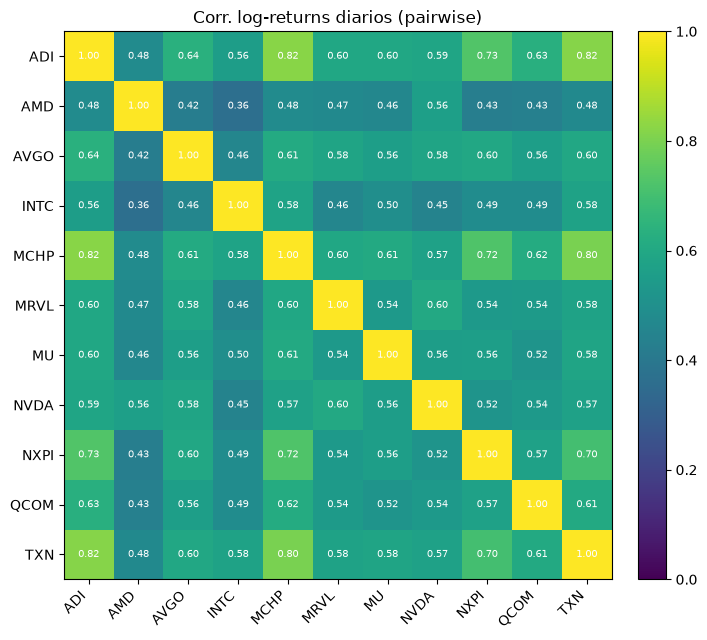

Top 5 pares más correlados:


,t1,t2,corr
3,ADI,MCHP,0.820750
9,ADI,TXN,0.817234
39,MCHP,TXN,0.797711
7,ADI,NXPI,0.729775
37,MCHP,NXPI,0.723820


Top 5 pares menos correlados:


,t1,t2,corr
11,AMD,INTC,0.364812
10,AMD,AVGO,0.424079
16,AMD,NXPI,0.427839
17,AMD,QCOM,0.434215
30,INTC,NVDA,0.447331


In [7]:
ret_wide = rets.pivot(index="date", columns="ticker", values="log_ret").sort_index()
# orden estable de columnas
ret_wide = ret_wide.reindex(columns=tickers)
corr = ret_wide.corr()
display(corr.round(3))

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(corr.values, vmin=0, vmax=1, cmap="viridis", aspect="equal")
ax.set_xticks(range(len(tickers)))
ax.set_yticks(range(len(tickers)))
ax.set_xticklabels(tickers, rotation=45, ha="right")
ax.set_yticklabels(tickers)
ax.set_title("Corr. log-returns diarios (pairwise)")
for i in range(len(tickers)):
    for j in range(len(tickers)):
        ax.text(j, i, f"{corr.values[i, j]:.2f}", ha="center", va="center", fontsize=7, color="w")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
maybe_save(fig, "02c_corr_returns.png")
plt.show()

# pares más / menos correlados (triángulo superior)
pairs = []
for i, a in enumerate(tickers):
    for b in tickers[i + 1 :]:
        pairs.append((a, b, float(corr.loc[a, b])))
pairs_df = pd.DataFrame(pairs, columns=["t1", "t2", "corr"]).sort_values("corr", ascending=False)
print("Top 5 pares más correlados:")
display(pairs_df.head(5))
print("Top 5 pares menos correlados:")
display(pairs_df.tail(5).sort_values("corr"))


## 8. Ticker drill-down

Parametrizable con `TICKER` en §1 (p. ej. `"NVDA"`, `"AMD"`, `"INTC"`).

<!-- Ampliar: marcar earnings / splits conocidos; zoom a un año concreto -->


=== drill-down: NVDA ===
días=3520 | 2012-01-03 → 2025-12-31 | Close[0.3214 → 186.3]


,count,mean,std,skew,kurtosis,min,max
NVDA,3519.0,0.001808,0.028091,0.17359,7.934565,-0.207712,0.260876


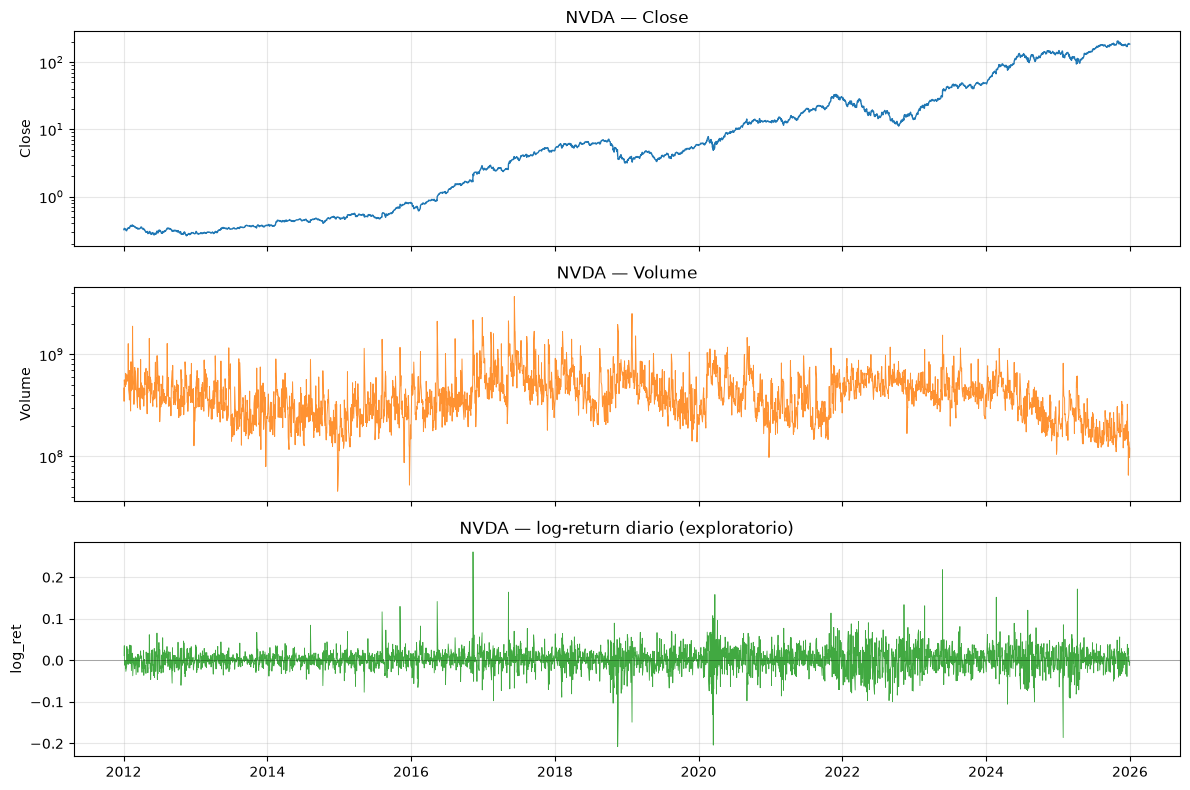

In [8]:
assert TICKER in tickers, f"{TICKER=} no está en el panel: {tickers}"

one = work.loc[work["ticker"] == TICKER].sort_values("date").copy()
one_rets = one.dropna(subset=["log_ret"])

print(f"=== drill-down: {TICKER} ===")
print(
    f"días={len(one)} | {one['date'].min().date()} → {one['date'].max().date()} | "
    f"Close[{one['Close'].iloc[0]:.4g} → {one['Close'].iloc[-1]:.4g}]"
)
display(
    one_rets["log_ret"]
    .agg(count="count", mean="mean", std="std", skew="skew", kurtosis="kurtosis", min="min", max="max")
    .to_frame(TICKER)
    .T.round(6)
)

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

axes[0].plot(one["date"], one["Close"], color="C0", linewidth=1.0)
axes[0].set_ylabel("Close")
axes[0].set_title(f"{TICKER} — Close")
if USE_LOG_SCALE:
    axes[0].set_yscale("log")
axes[0].grid(True, alpha=0.3)

axes[1].plot(one["date"], one["Volume"], color="C1", linewidth=0.7, alpha=0.85)
axes[1].set_ylabel("Volume")
axes[1].set_title(f"{TICKER} — Volume")
axes[1].set_yscale("log")
axes[1].grid(True, alpha=0.3)
# marcar Volume==0 si existe
z = one.loc[one["Volume"] == 0]
if len(z):
    axes[1].scatter(z["date"], np.maximum(z["Volume"], 1), color="red", s=40, zorder=5, label="Volume==0")
    axes[1].legend(fontsize=8)

axes[2].plot(one_rets["date"], one_rets["log_ret"], color="C2", linewidth=0.6, alpha=0.9)
axes[2].axhline(0, color="k", linewidth=0.5, alpha=0.4)
axes[2].set_ylabel("log_ret")
axes[2].set_title(f"{TICKER} — log-return diario (exploratorio)")
axes[2].grid(True, alpha=0.3)

fig.tight_layout()
maybe_save(fig, f"02c_drilldown_{TICKER}.png")
plt.show()


## 9. Hallazgos abiertos

Lista **editable** — ir añadiendo lo que salga al explorar. No son decisiones cerradas.

### Observaciones iniciales (tras primera pasada)

- Panel limpio: **38 713** filas, **11** tickers (ADI, AMD, AVGO, INTC, MCHP, MRVL, MU, NVDA, NXPI, QCOM, TXN), **2012-01-03 → 2025-12-31**, calendario unión **3 520** fechas.
- Cobertura casi completa; huecos vs unión: INTC 3, MCHP 2, MRVL 1, TXN 1 (resto 0). Coherente con `clean_manifest.json`.
- **1** fila con `Volume == 0`: AMD **2015-01-02** (Close 2.67). Raro; no corregir aquí.
- Volatilidad heterogénea de log-returns diarios: AMD σ≈**0.035**, TXN/ADI ≈**0.018**; kurtosis elevada en todos (INTC ~**19**).
- Rango intradía relativo mayor en AMD / MU / MRVL / NVDA; menor en TXN / ADI (~2%).
- Correlaciones altas en cluster **ADI–MCHP–TXN–NXPI** (~0.70–0.82); AMD suele ser el par menos correlado con el resto.
- Colas: ~24 días con `|log_ret| > 0.20` (p. ej. AMD +42% el 2016-04-22; INTC −30% el 2024-08-02).


---

**Fin del esqueleto inicial.** Añade celdas debajo o entre secciones. Recuerda: **solo lectura** sobre `data/clean/`.
